## Setup

In [1]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import threading
import asyncio
import matplotlib.pyplot as plt

LOG.propagate = False

## Connect

In [17]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.reload_config()
ble.connect()

2026-02-04 00:20:01,812 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:d1:79:ab:49
2026-02-04 00:20:01,813 | INFO     |: Scanning for device with address: c0:42:d1:79:ab:49, service UUID: 4843fd62-068c-4a37-af34-e724c6a05681
2026-02-04 00:20:11,935 | INFO     |: Found 30 total devices
2026-02-04 00:20:11,936 | INFO     |: Found matching device: C0:42:D1:79:AB:49 (name: Artemis BLE)
2026-02-04 00:20:13,187 | INFO     |: Connected to c0:42:d1:79:ab:49


## Disconnect

In [ ]:
ble.disconnect()

## Echo

In [ ]:
# Send the message
ble.send_command(CMD.ECHO, "Hello World!")

# Check that the board received it and returns it
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

## Send Three Floats

In [ ]:
ble.send_command(CMD.SEND_THREE_FLOATS, "3.14|5.25|7.432")

## Get Time Millis

In [ ]:
# Send command
ble.send_command(CMD.GET_TIME_MILLIS, "")

# Check board message
s = ble.receive_string(ble.uuid['RX_STRING'])
print("Recieved from board: " + s)

## Notification Handler

In [ ]:
def notification_callback(uuid, charac_bytearray):
    msg = ble.bytearray_to_string(charac_bytearray)
    if msg.startswith("T:"):
        t_ms = int(msg.split(":")[1])
        print("Time (ms):", t_ms)
    else:
        print("Unexpected message:", msg)

duration_s = 0.3  # set collection time

# Set up callback
ble.start_notify(ble.uuid['RX_STRING'], notification_callback)

t0 = time.time()
while (time.time() - t0) < duration_s:
    time.sleep(0.01)   # small sleep so you don't busy-wait

ble.stop_notify(ble.uuid['RX_STRING'])
print("End time notify")




## Time Array

In [ ]:
done = threading.Event()
time_values = []

def time_array_notification_callback(uuid, data: bytearray):
    msg = ble.bytearray_to_string(data).strip()
    print("Msg received:", repr(msg))

    parts = [p.strip() for p in msg.split(",") if p.strip()]
    if parts and parts[-1].lower() == "end":
        time_values.extend(parts[:-1])
        print("End of values")
        done.set()
        return
    time_values.extend(parts)

def get_time_data(timeout_s=10.0):
    time_values.clear()
    done.clear()
    
    # send command (NO await)
    ble.send_command(CMD.SEND_TIME_DATA, "")

    t0 = time.time()
    while not done.is_set() and (time.time() - t0) < timeout_s:
        ble.sleep(0.01)

    if not done.is_set():
        print("Timeout reached.")
    return list(time_values)

# start notify
try:
    ble.start_notify(ble.uuid['RX_STRING'], time_array_notification_callback)
except Exception as e:
    if "Notify acquired" in str(e):
        print("Notify already active; continuing.")
time.sleep(0.2)

vals = get_time_data()
print(vals)

try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except Exception as e:
    print("Failed to stop notifications with exception: ", e)


## Temp Readings

In [ ]:
done = threading.Event()
time_values = []
temp_values = []

def temp_array_notification_callback(uuid, data: bytearray):
    msg = ble.bytearray_to_string(data).strip()
    print("Msg received:", repr(msg))

    parts = [p.strip() for p in msg.split(",") if p.strip()]
    for token in parts:
        if token.lower() == "end":
            print("End of values")
            done.set()
            return

        try:
            time_str, t_str = token.split(":", 1)
            temp_values.append(int(t_str))
            time_values.append(int(time_str))
        except ValueError:
            print("Bad token:", repr(token))

def get_temp_data(timeout_s=10.0):
    time_values.clear()
    temp_values.clear()
    done.clear()
    
    # send command (NO await)
    ble.send_command(CMD.GET_TEMP_READINGS, "")

    t0 = time.time()
    while not done.is_set() and (time.time() - t0) < timeout_s:
        ble.sleep(0.01)

    if not done.is_set():
        print("Timeout reached.")
    return list(temp_values), list(time_values)

# start notify
try:
    ble.start_notify(ble.uuid['RX_STRING'], temp_array_notification_callback)
except Exception as e:
    if "Notify acquired" in str(e):
        print("Notify already active; continuing.")
time.sleep(0.2)

temp_vals, time_vals = get_temp_data()

print("Temp array length: ", len(temp_values))
print("Time array length: ", len(time_values))
print("Temp values: ",temp_vals)
print("Time values:", time_vals)

try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except Exception as e:
    print("Failed to stop notifications with exception: ", e)


## Data Rate

Sending request for 1 bytes...
Sending request for 5 bytes...
Callback: len=1
Sending request for 10 bytes...
Callback: len=5
Sending request for 25 bytes...
Callback: len=10
Sending request for 50 bytes...
Callback: len=25
Sending request for 100 bytes...
Callback: len=50
Sending request for 120 bytes...
Callback: len=100
Sending dummy request to flush...
Callback: len=120

Received 7 responses
  Size: 1
  Size: 5
  Size: 10
  Size: 25
  Size: 50
  Size: 100
  Size: 120

--- Data Rate Results ---
  1 bytes: RTT = 172.70 ms, One-way = 86.35 ms, Data rate = 11.58 bytes/sec
  5 bytes: RTT = 195.17 ms, One-way = 97.58 ms, Data rate = 51.24 bytes/sec
 10 bytes: RTT = 195.04 ms, One-way = 97.52 ms, Data rate = 102.55 bytes/sec
 25 bytes: RTT = 195.19 ms, One-way = 97.59 ms, Data rate = 256.17 bytes/sec
 50 bytes: RTT = 195.07 ms, One-way = 97.54 ms, Data rate = 512.63 bytes/sec
100 bytes: RTT = 195.18 ms, One-way = 97.59 ms, Data rate = 1024.68 bytes/sec
120 bytes: RTT = 195.16 ms, One-way 

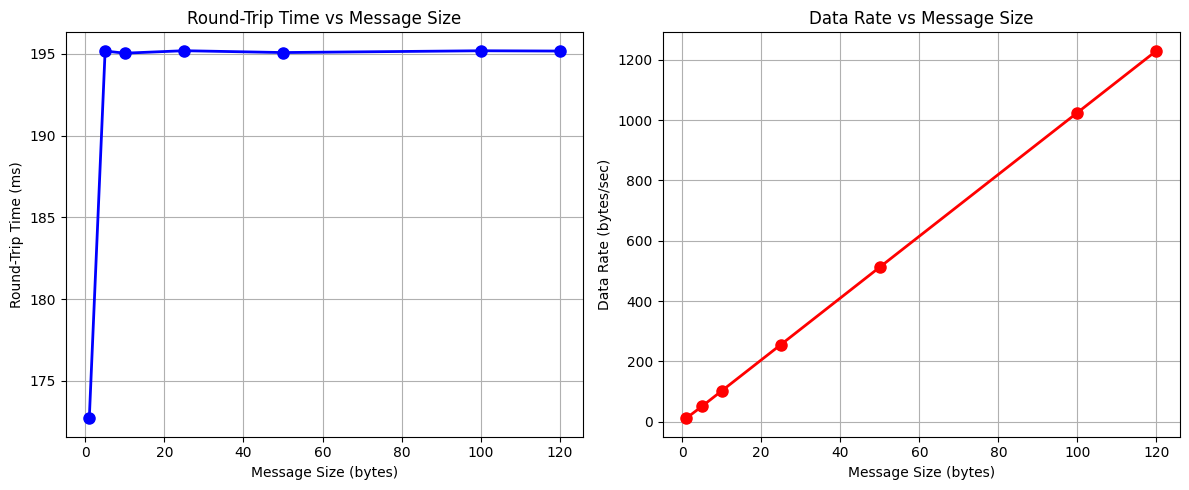

In [19]:
# Code generated by AI
msg_sizes = [5, 10, 25, 50, 100, 120]
transmit_times = {}
received_data = []

def data_rate_callback(uuid, data: bytearray):
    msg = ble.bytearray_to_string(data).strip()
    rx_time = time.perf_counter()
    size = len(msg)
    received_data.append((rx_time, size))
    print(f"Callback: len={size}")

# Start notify
try:
    ble.start_notify(ble.uuid['RX_STRING'], data_rate_callback)
except Exception as e:
    if "Notify acquired" in str(e):
        print("Notify already active; continuing.")

time.sleep(1.0)
received_data.clear()

# Send all requests, recording transmit times by size
for size in msg_sizes:
    print(f"Sending request for {size} bytes...")
    transmit_times[size] = time.perf_counter()
    ble.send_command(CMD.DATA_RATE, str(size))
    time.sleep(0.1)  # Short delay between sends

# Send a dummy request immediately to flush the last real response
print("Sending dummy request to flush...")
ble.send_command(CMD.DATA_RATE, "1")
time.sleep(1.0)  # Wait for all responses

# Stop notifications
try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except Exception as e:
    print("Failed to stop notifications")

# Debug output
print(f"\nReceived {len(received_data)} responses")
for rx_time, size in received_data:
    print(f"  Size: {size}")

# Match received responses to transmit times by size
# Filter out the dummy response (size 1)
results = []
for rx_time, size in received_data:
    if size in transmit_times and size in msg_sizes:
        rtt = rx_time - transmit_times[size]
        results.append((size, rtt))

# Sort by size
results.sort(key=lambda x: x[0])

# Display results
print("\n--- Data Rate Results ---")
actual_sizes = []
round_trip_times = []
data_rates = []

for size, rtt in results:
    one_way = rtt / 2
    rate = size / one_way
    actual_sizes.append(size)
    round_trip_times.append(rtt * 1000)
    data_rates.append(rate)
    print(f"{size:3d} bytes: RTT = {rtt*1000:.2f} ms, "
          f"One-way = {one_way*1000:.2f} ms, "
          f"Data rate = {rate:.2f} bytes/sec")

# Plot
if len(results) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(actual_sizes, round_trip_times, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Message Size (bytes)')
    ax1.set_ylabel('Round-Trip Time (ms)')
    ax1.set_title('Round-Trip Time vs Message Size')
    ax1.grid(True)

    ax2.plot(actual_sizes, data_rates, 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Message Size (bytes)')
    ax2.set_ylabel('Data Rate (bytes/sec)')
    ax2.set_title('Data Rate vs Message Size')
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('ble_data_rate.png')
    plt.show()